# 7.3.网络中的网络（NiN）

LeNet、AlexNet和VGG都有一个共同的设计模式：通过一系列的卷积层与汇聚层来提取空间结构特征；然后通过全连接层对特征的表征进行处理。AlexNet和VGG对LeNet的改进主要在于如何扩大和加深这两个模块。或者，可以想象在这个过程的早期使用全连接层。然而，如果使用了全连接层，可能会完全放弃表征的空间结构。*网络中的网络*（*NiN*）提供了一个非常简单的解决方案：在每个像素的通道上分别使用多层感知机 [[Lin et al., 2013]](https://zh.d2l.ai/chapter_references/zreferences.html#id93)



---


## 环境准备


In [2]:
%matplotlib inline
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"

import pypto
import torch
import torchvision
from torch import nn
from src.D2LFunction import *
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTODropoutModule import PyPTODropout

---


## 7.3.1.NiN块

回想一下，卷积层的输入和输出由四维张量组成，张量的每个轴分别对应样本、通道、高度和宽度。另外，全连接层的输入和输出通常是分别对应于样本和特征的二维张量。NiN的想法是在每个像素位置（针对每个高度和宽度）应用一个全连接层。如果我们将权重连接到每个空间位置，我们可以将其视为$1\times 1$卷积层（如 [<span style="color: #ffbf00; font-weight: bold;"> 6.4节 </span>](../06_pypto_convolutional_networks/06.04_channels.ipynb)中所述），或作为在每个像素位置上独立作用的全连接层。从另一个角度看，即将空间维度中的每个像素视为单个样本，将通道维度视为不同特征（feature）。

 <span style="color: #ffbf00; font-weight: bold;"> 图7.3.1 </span>说明了VGG和NiN及它们的块之间主要架构差异。NiN块以一个普通卷积层开始，后面是两个$1 \times 1$的卷积层。这两个$1 \times 1$卷积层充当带有ReLU激活函数的逐像素全连接层。第一层的卷积窗口形状通常由用户设置。随后的卷积窗口形状固定为$1 \times 1$。

<div style="border: solid 16px #f1f1f8; text-align: center; background-color: #f6f7f9">
<img src="./images/nin.svg" style="width: 600px">
<p style="margin: 12px 0 4px 0; font-size: 0.9em; color: #555; text-align: center;">图7.3.1 对比 VGG 和 NiN 及它们的块之间主要架构差异。</p>
</div>
<br />


In [3]:
def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        PyPTOConv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        PyPTOConv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        PyPTOConv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())</pre>
</div>
</details>

---


## 7.3.2.NiN模型

最初的NiN网络是在AlexNet后不久提出的，显然从中得到了一些启示。NiN使用窗口形状为$11\times 11$、$5\times 5$和$3\times 3$的卷积层，输出通道数量与AlexNet中的相同。每个NiN块后有一个最大汇聚层，汇聚窗口形状为$3\times 3$，步幅为2。

NiN和AlexNet之间的一个显著区别是NiN完全取消了全连接层。相反，NiN使用一个NiN块，其输出通道数等于标签类别的数量。最后放一个*全局平均汇聚层*（global average pooling layer），生成一个对数几率	（logits）。NiN设计的一个优点是，它显著减少了模型所需参数的数量。然而，在实践中，这种设计有时会增加训练模型的时间。


In [4]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    PyPTOMaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    PyPTOMaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    PyPTOMaxPool2d(3, stride=2),
    PyPTODropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten()).to('npu:0')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())</pre>
</div>
</details>

我们创建一个数据样本来查看每个块的输出形状。


In [5]:
X = torch.rand(size=(1, 1, 96, 96), device='npu:0')
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 22, 22])
PyPTOMaxPool2d output shape:	 torch.Size([1, 96, 10, 10])
Sequential output shape:	 torch.Size([1, 256, 10, 10])
PyPTOMaxPool2d output shape:	 torch.Size([1, 256, 4, 4])
Sequential output shape:	 torch.Size([1, 384, 4, 4])
PyPTOMaxPool2d output shape:	 torch.Size([1, 384, 1, 1])


PyPTODropout output shape:	 torch.Size([1, 384, 1, 1])
Sequential output shape:	 torch.Size([1, 10, 1, 1])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


---


## 7.3.3.训练模型

和以前一样，我们使用Fashion-MNIST来训练模型。训练NiN与训练AlexNet、VGG时相似。


loss 0.272, train acc 0.904, test acc 0.901
142.9 examples/sec on npu:0


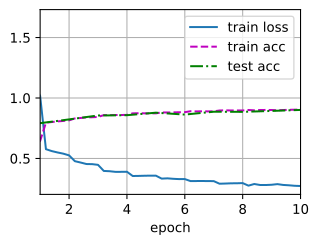

In [7]:
lr, num_epochs, batch_size = 0.001, 10, 16
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=96)
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

---


## 7.3.4.小结

* NiN使用由一个卷积层和多个$1\times 1$卷积层组成的块。该块可以在卷积神经网络中使用，以允许更多的每像素非线性。
* NiN去除了容易造成过拟合的全连接层，将它们替换为全局平均汇聚层（即在所有位置上进行求和）。该汇聚层通道数量为所需的输出数量（例如，Fashion-MNIST的输出为10）。
* 移除全连接层可减少过拟合，同时显著减少NiN的参数。
* NiN的设计影响了许多后续卷积神经网络的设计。



---


## 7.3.5.练习

1. 调整NiN的超参数，以提高分类准确性。
2. 为什么NiN块中有两个$1\times 1$卷积层？删除其中一个，然后观察和分析实验现象。
3. 计算NiN的资源使用情况。
    1. 参数的数量是多少？
    2. 计算量是多少？
    3. 训练期间需要多少显存？
    4. 预测期间需要多少显存？
4. 一次性直接将$384 \times 5 \times 5$的表示缩减为$10 \times 5 \times 5$的表示，会存在哪些问题？


参考答案详见 [answers/07.03_reference_answer](./answers/07.03_reference_answer.ipynb)。

### 7.3.5.1.参考答案（PyPTO）


In [ ]:
!cat answers/txt/07.03_reference_answer_pypto.txt

### 7.3.5.2.参考答案（PyTorch）


In [ ]:
!cat answers/txt/07.03_reference_answer_pytorch.txt